# EDA y Limpieza — BBDD ONSV Siniestros Fatales 2021–2025
**Curso:** Agentes Inteligentes | **Grupo 5**

### Estructura del notebook
1. Carga directa desde `.xlsx` (sin conversión, sin problemas de encoding)
2. Inspección dinámica — sin asumir columnas
3. Análisis de nulos con distinción estructural vs. omisión real
4. Limpieza e imputación (incluye corrección de tipo en LONGITUD)
5. Feature engineering justificado
6. Variable objetivo multicategórica con justificación en literatura
7. Visualizaciones exploratorias
8. Exportación del dataset limpio

## 1. Carga directa desde Excel

Se lee el archivo `.xlsx` original del ONSV directamente con `openpyxl`.
Esto evita cualquier problema de encoding que ocurre al convertir a CSV,
ya que Excel maneja internamente Unicode.

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

BASE_DIR = Path.cwd().resolve()
if BASE_DIR.name == 'notebooks':
    BASE_DIR = BASE_DIR.parent
DIR_FIGURAS = BASE_DIR / 'outputs' / 'figures'
DIR_PROCESADA = BASE_DIR / 'data' / 'procesada'
DIR_FIGURAS.mkdir(parents=True, exist_ok=True)
DIR_PROCESADA.mkdir(parents=True, exist_ok=True)
RUTA_XLSX = BASE_DIR / 'data' / 'raw' / 'BBDD ONSV - SINIESTROS FATALES 2021-2025 (preliminar).xlsx'

# El archivo tiene 4 filas de metadata antes de los headers reales
df_raw = pd.read_excel(RUTA_XLSX, sheet_name=0, skiprows=4, engine='openpyxl')

# Limpiar nombres de columnas: quitar espacios extra
df_raw.columns = df_raw.columns.str.strip()

print(f'Dimensiones cargadas: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas')
print('\nColumnas detectadas:')
for i, col in enumerate(df_raw.columns):
    print(f'  [{i:02d}] {col}')

Dimensiones cargadas: 9,106 filas × 27 columnas

Columnas detectadas:
  [00] CÓDIGO SINIESTRO
  [01] FECHA SINIESTRO
  [02] HORA SINIESTRO
  [03] CLASE SINIESTRO
  [04] CANTIDAD DE FALLECIDOS
  [05] CANTIDAD DE LESIONADOS
  [06] CANTIDAD DE VEHICULOS DAÑADOS
  [07] DEPARTAMENTO
  [08] PROVINCIA
  [09] DISTRITO
  [10] ZONA
  [11] TIPO DE VÍA
  [12] RED VIAL
  [13] COD CARRETERA
  [14] COORDENADAS LATITUD
  [15] COORDENADAS  LONGITUD
  [16] CONDICIÓN CLIMÁTICA
  [17] ZONIFICACIÓN
  [18] CARACTERÍSTICAS DE VÍA
  [19] PERFIL LONGITUDINAL VÍA
  [20] SUPERFICIE DE CALZADA
  [21] ¿EXISTE SEÑAL VERTICAL?
  [22] CLASIFICACIÓN DE LA SEÑAL VERTICAL Nº 1
  [23] CLASIFICACIÓN DE LA SEÑAL VERTICAL Nº 2
  [24] ¿EXISTE SEÑAL HORIZONTAL?
  [25] CAUSA FACTOR PRINCIPAL
  [26] CAUSA ESPECÍFICA


## 2. Inspección general dinámica

Se inspeccionan tipos de datos y estadísticas sin asumir qué columnas existen.

In [115]:
# Tipos de datos detectados automáticamente
print('=== Tipos de datos ===')
print(df_raw.dtypes)
print(f'\nTotal de columnas numéricas: {df_raw.select_dtypes(include=np.number).shape[1]}')
print(f'Total de columnas categóricas/texto: {df_raw.select_dtypes(include="object").shape[1]}')

=== Tipos de datos ===
CÓDIGO SINIESTRO                               str
FECHA SINIESTRO                             object
HORA SINIESTRO                                 str
CLASE SINIESTRO                                str
CANTIDAD DE FALLECIDOS                       int64
CANTIDAD DE LESIONADOS                       int64
CANTIDAD DE VEHICULOS DAÑADOS              float64
DEPARTAMENTO                                   str
PROVINCIA                                      str
DISTRITO                                       str
ZONA                                           str
TIPO DE VÍA                                    str
RED VIAL                                       str
COD CARRETERA                                  str
COORDENADAS LATITUD                        float64
COORDENADAS  LONGITUD                       object
CONDICIÓN CLIMÁTICA                            str
ZONIFICACIÓN                                   str
CARACTERÍSTICAS DE VÍA                         str
PERFIL L

/tmp/ipykernel_75092/4286289568.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(f'Total de columnas categóricas/texto: {df_raw.select_dtypes(include="object").shape[1]}')


In [116]:
# Estadísticas descriptivas solo de columnas numéricas detectadas
cols_numericas = df_raw.select_dtypes(include=np.number).columns.tolist()
print(f'Columnas numéricas: {cols_numericas}')
df_raw[cols_numericas].describe().round(2)

Columnas numéricas: ['CANTIDAD DE FALLECIDOS', 'CANTIDAD DE LESIONADOS', 'CANTIDAD DE VEHICULOS DAÑADOS', 'COORDENADAS LATITUD']


,CANTIDAD DE FALLECIDOS,CANTIDAD DE LESIONADOS,CANTIDAD DE VEHICULOS DAÑADOS,COORDENADAS LATITUD
count,9106.00,9106.00,6293.00,9106.00
mean,1.19,0.86,1.27,-11.30
std,0.98,2.84,0.69,3.64
min,1.00,0.00,0.00,-18.31
25%,1.00,0.00,1.00,-13.84
50%,1.00,0.00,1.00,-12.03
75%,1.00,1.00,2.00,-8.02
max,33.00,71.00,15.00,-3.48


In [117]:
# Cardinalidad de columnas categóricas (valores únicos)
cols_cat = df_raw.select_dtypes(include='object').columns.tolist()
print('=== Valores únicos por columna categórica ===')
for col in cols_cat:
    unicos = df_raw[col].nunique(dropna=True)
    print(f'  {col}: {unicos} valores únicos')

=== Valores únicos por columna categórica ===
  CÓDIGO SINIESTRO: 9106 valores únicos
  FECHA SINIESTRO: 1729 valores únicos
  HORA SINIESTRO: 651 valores únicos
  CLASE SINIESTRO: 11 valores únicos
  DEPARTAMENTO: 25 valores únicos
  PROVINCIA: 182 valores únicos
  DISTRITO: 1086 valores únicos
  ZONA: 2 valores únicos
  TIPO DE VÍA: 13 valores únicos
  RED VIAL: 5 valores únicos
  COD CARRETERA: 1045 valores únicos
  COORDENADAS  LONGITUD: 9095 valores únicos
  CONDICIÓN CLIMÁTICA: 8 valores únicos
  ZONIFICACIÓN: 5 valores únicos
  CARACTERÍSTICAS DE VÍA: 9 valores únicos
  PERFIL LONGITUDINAL VÍA: 2 valores únicos
  SUPERFICIE DE CALZADA: 7 valores únicos
  ¿EXISTE SEÑAL VERTICAL?: 2 valores únicos
  CLASIFICACIÓN DE LA SEÑAL VERTICAL Nº 1: 3 valores únicos
  CLASIFICACIÓN DE LA SEÑAL VERTICAL Nº 2: 3 valores únicos
  ¿EXISTE SEÑAL HORIZONTAL?: 2 valores únicos
  CAUSA FACTOR PRINCIPAL: 7 valores únicos
  CAUSA ESPECÍFICA: 38 valores únicos


/tmp/ipykernel_75092/2732677833.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_cat = df_raw.select_dtypes(include='object').columns.tolist()


## 3. Análisis de valores faltantes

Se distingue entre dos tipos de nulos (Gao et al., 2025):
- **Nulos estructurales**: campos que no aplican por la naturaleza del registro (ej. clasificación de señal cuando no existe señal)
- **Omisiones reales**: datos que debieron registrarse pero no se capturaron

In [118]:
# Análisis dinámico de nulos — se adapta a cualquier columna presente
nulos = df_raw.isnull().sum()
pct_nulos = (nulos / len(df_raw) * 100).round(2)

resumen_nulos = pd.DataFrame({
    'Nulos': nulos,
    '% Nulos': pct_nulos,
    'Tipo': 'numérica'
})
resumen_nulos.loc[df_raw.select_dtypes('object').columns, 'Tipo'] = 'categórica'
resumen_nulos = resumen_nulos[resumen_nulos['Nulos'] > 0].sort_values('% Nulos', ascending=False)

print('=== Columnas con valores faltantes ===')
print(resumen_nulos.to_string())

=== Columnas con valores faltantes ===
                                         Nulos  % Nulos        Tipo
CLASIFICACIÓN DE LA SEÑAL VERTICAL Nº 2   8572    94.14  categórica
CLASIFICACIÓN DE LA SEÑAL VERTICAL Nº 1   7790    85.55  categórica
¿EXISTE SEÑAL VERTICAL?                   7090    77.86  categórica
¿EXISTE SEÑAL HORIZONTAL?                 7090    77.86  categórica
CANTIDAD DE VEHICULOS DAÑADOS             2813    30.89    numérica
PERFIL LONGITUDINAL VÍA                    424     4.66  categórica
CARACTERÍSTICAS DE VÍA                     423     4.65  categórica
CONDICIÓN CLIMÁTICA                        423     4.65  categórica
ZONIFICACIÓN                               423     4.65  categórica
SUPERFICIE DE CALZADA                      423     4.65  categórica
CAUSA ESPECÍFICA                            82     0.90  categórica
ZONA                                        38     0.42  categórica
COD CARRETERA                                1     0.01  categórica


/tmp/ipykernel_75092/1594645138.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  resumen_nulos.loc[df_raw.select_dtypes('object').columns, 'Tipo'] = 'categórica'


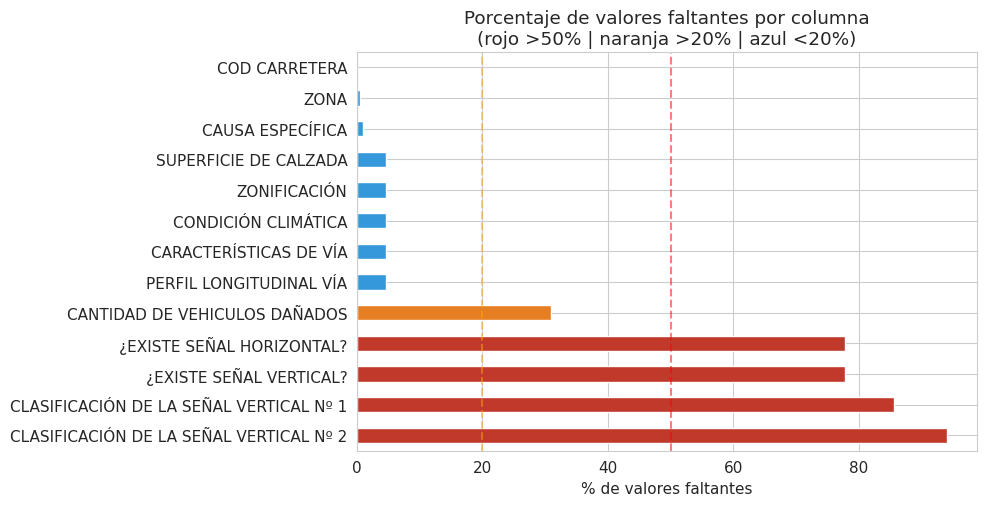

In [119]:
# Visualización de nulos
if len(resumen_nulos) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(resumen_nulos) * 0.4)))
    colors = ['#c0392b' if p > 50 else '#e67e22' if p > 20 else '#3498db'
              for p in resumen_nulos['% Nulos']]
    resumen_nulos['% Nulos'].plot(kind='barh', ax=ax, color=colors)
    ax.set_xlabel('% de valores faltantes')
    ax.set_title('Porcentaje de valores faltantes por columna\n'
                 '(rojo >50% | naranja >20% | azul <20%)')
    ax.axvline(50, color='red', linestyle='--', alpha=0.5)
    ax.axvline(20, color='orange', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(DIR_FIGURAS / 'nulos_por_columna.png', dpi=150)
    plt.show()

## 4. Limpieza e Imputación

**Criterio metodológico (Gao et al., 2025; Han et al., 2012):**
Los nulos en columnas de señalización son estructurales — si no existe señal, los campos de clasificación no aplican y no deben tratarse como datos faltantes reales. Se imputan como categoría `'SIN_DATO'` para preservar esa información.

Las demás columnas categóricas con nulos reciben `'SIN_DATO'`, y las numéricas reciben la mediana. **Se compara la distribución antes y después para verificar que no se distorsionan los datos.**

Adicionalmente, la columna de LONGITUD es corregida de `object` a numérico en esta fase, ya que es un problema de calidad del dato de origen — no una decisión de modelado (Han et al., 2012).

In [120]:
df = df_raw.copy()

# --- Detección dinámica de columnas con nulos ---
cols_con_nulos = df.columns[df.isnull().any()].tolist()
cols_cat_nulos = [c for c in cols_con_nulos if df[c].dtype == 'object']
cols_num_nulos = [c for c in cols_con_nulos if df[c].dtype != 'object']

print(f'Columnas categóricas con nulos ({len(cols_cat_nulos)}): {cols_cat_nulos}')
print(f'Columnas numéricas con nulos ({len(cols_num_nulos)}): {cols_num_nulos}')

Columnas categóricas con nulos (0): []
Columnas numéricas con nulos (13): ['CANTIDAD DE VEHICULOS DAÑADOS', 'ZONA', 'COD CARRETERA', 'CONDICIÓN CLIMÁTICA', 'ZONIFICACIÓN', 'CARACTERÍSTICAS DE VÍA', 'PERFIL LONGITUDINAL VÍA', 'SUPERFICIE DE CALZADA', '¿EXISTE SEÑAL VERTICAL?', 'CLASIFICACIÓN DE LA SEÑAL VERTICAL Nº 1', 'CLASIFICACIÓN DE LA SEÑAL VERTICAL Nº 2', '¿EXISTE SEÑAL HORIZONTAL?', 'CAUSA ESPECÍFICA']


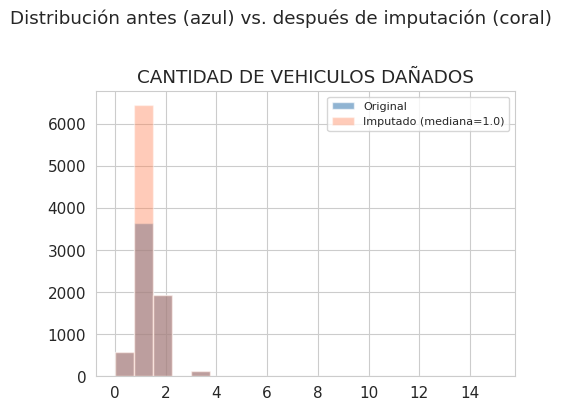

Imputación numérica aplicada para columnas: CANTIDAD DE VEHICULOS DAÑADOS


In [121]:
# --- Comparación antes/después para columnas numéricas ---
# Detectar columnas numéricas entre las que tienen nulos intentando coerción a numérico
cols_num_nulos = []
for c in cols_con_nulos:
    coerced = pd.to_numeric(df[c], errors='coerce')
    # Si al menos un valor es numérico, tratamos la columna como numérica
    if coerced.notna().sum() > 0:
        cols_num_nulos.append(c)

if cols_num_nulos:
    import math
    n = len(cols_num_nulos)
    ncols = min(3, n)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    # Normalizar axes a lista plana
    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = [axes]

    medianas = {}
    for i, col in enumerate(cols_num_nulos):
        ax = axes[i]
        col_num = pd.to_numeric(df[col], errors='coerce')
        mediana = col_num.median()
        medianas[col] = mediana

        # Plot original (solo valores válidos) y distribución imputada (con mediana)
        col_num.dropna().hist(ax=ax, bins=20, alpha=0.6, color='steelblue', label='Original')
        col_num.fillna(mediana).hist(ax=ax, bins=20, alpha=0.4, color='coral', label=f'Imputado (mediana={mediana:.1f})')
        ax.set_title(col)
        ax.legend(fontsize=8)

    # Ocultar ejes no usados si hay espacio extra
    for j in range(len(cols_num_nulos), len(axes)):
        try:
            axes[j].axis('off')
        except Exception:
            pass

    plt.suptitle('Distribución antes (azul) vs. después de imputación (coral)', y=1.02)
    plt.tight_layout()
    plt.savefig(DIR_FIGURAS / 'comparacion_imputacion_numerica.png', dpi=150)
    plt.show()

    # Aplicar imputación numérica de forma segura (reconvirtiendo y rellenando)
    for col, mediana in medianas.items():
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(mediana)
    print('Imputación numérica aplicada para columnas: ' + ', '.join(medianas.keys()))
else:
    print('No hay columnas numéricas detectadas entre las columnas con nulos.')

In [122]:
# --- Comparación antes/después para columnas categóricas ---
if cols_cat_nulos:
    print('=== Distribución de nulos antes de imputar (categóricas) ===')
    for col in cols_cat_nulos:
        pct = df[col].isnull().mean() * 100
        print(f'  {col}: {pct:.1f}% nulos → se imputará como SIN_DATO')

    # Aplicar imputación categórica
    for col in cols_cat_nulos:
        df[col] = df[col].fillna('SIN_DATO')

    print('\nNulos restantes después de imputación:')
    print(df[cols_cat_nulos].isnull().sum())

In [123]:
# Verificación final — no debe quedar ningún nulo en columnas imputadas
# Recalcular columnas con nulos tras las imputaciones y aplicar correcciones finales si es necesario
cols_con_nulos = df.columns[df.isnull().any()].tolist()
if len(cols_con_nulos) == 0:
    print('✓ Verificación pasada: no quedan nulos en columnas imputadas.')
else:
    print('⚠ Quedan columnas con nulos después de la imputación:', cols_con_nulos)
    # Intentar una última pasada: coerción a numérico y rellenado por mediana cuando tenga sentido,
    # y para el resto rellenar con 'SIN_DATO'
    for col in cols_con_nulos:
        coerced = pd.to_numeric(df[col], errors='coerce')
        if coerced.notna().sum() > 0:
            med = coerced.median()
            df[col] = coerced.fillna(med)
            print(f'  - {col}: rellenado con mediana numérica ({med})')
        else:
            df[col] = df[col].fillna('SIN_DATO')
            print(f'  - {col}: rellenado con "SIN_DATO" (categórica/no convertible)')
    # Re-evaluar
    nulos_post = df.isnull().sum()
    nulos_post = nulos_post[nulos_post > 0]
    if nulos_post.empty:
        print('✓ Verificación pasada tras corrección final: no quedan nulos.')
    else:
        print('✗ Aún quedan nulos en columnas:', nulos_post.to_dict())
print(f'  Registros preservados: {len(df):,} (sin eliminación de filas)')
# --- Conversión a entero de columnas numéricas discretas ---
col_veh = next((c for c in df.columns if 'VEHICULOS' in c.upper()), None)
if col_veh:
    # Si la columna es numérica, convertir a int; si no, intentar coerción primero
    try:
        df[col_veh] = df[col_veh].astype(int)
    except Exception:
        df[col_veh] = pd.to_numeric(df[col_veh], errors='coerce').fillna(0).astype(int)
    print(f'\n{col_veh}: convertida a {df[col_veh].dtype} (era float64 por nulos en origen)')


⚠ Quedan columnas con nulos después de la imputación: ['ZONA', 'COD CARRETERA', 'CONDICIÓN CLIMÁTICA', 'ZONIFICACIÓN', 'CARACTERÍSTICAS DE VÍA', 'PERFIL LONGITUDINAL VÍA', 'SUPERFICIE DE CALZADA', '¿EXISTE SEÑAL VERTICAL?', 'CLASIFICACIÓN DE LA SEÑAL VERTICAL Nº 1', 'CLASIFICACIÓN DE LA SEÑAL VERTICAL Nº 2', '¿EXISTE SEÑAL HORIZONTAL?', 'CAUSA ESPECÍFICA']
  - ZONA: rellenado con "SIN_DATO" (categórica/no convertible)
  - COD CARRETERA: rellenado con "SIN_DATO" (categórica/no convertible)
  - CONDICIÓN CLIMÁTICA: rellenado con "SIN_DATO" (categórica/no convertible)
  - ZONIFICACIÓN: rellenado con "SIN_DATO" (categórica/no convertible)
  - CARACTERÍSTICAS DE VÍA: rellenado con "SIN_DATO" (categórica/no convertible)
  - PERFIL LONGITUDINAL VÍA: rellenado con "SIN_DATO" (categórica/no convertible)
  - SUPERFICIE DE CALZADA: rellenado con "SIN_DATO" (categórica/no convertible)
  - ¿EXISTE SEÑAL VERTICAL?: rellenado con "SIN_DATO" (categórica/no convertible)
  - CLASIFICACIÓN DE LA SEÑAL VE

### 4.1 Corrección de tipo en LONGITUD

La columna de longitud es cargada por pandas como `object` porque el Excel original
contiene al menos una celda con valor no numérico (texto, espacio, guion).
Esto es un problema de calidad del dato de origen — se corrige aquí en la fase
de limpieza, no en la preparación para modelado (Han et al., 2012).

Se usa `errors='coerce'` para convertir valores no convertibles a NaN,
que luego se imputan con la mediana de la columna.

In [124]:
col_lon = next((c for c in df.columns if 'LONGITUD' in c.upper()), None)
print(f'Columna longitud detectada: {col_lon} | tipo actual: {df[col_lon].dtype}')

if col_lon and df[col_lon].dtype == 'object':
    # Inspeccionar valores problemáticos antes de convertir
    problematicos = pd.to_numeric(df[col_lon], errors='coerce').isnull()
    n_prob = problematicos.sum()
    print(f'Valores no numéricos encontrados: {n_prob}')
    if n_prob > 0:
        print('Muestra:')
        print(df.loc[problematicos, col_lon].value_counts().head(5))

    # Convertir e imputar
    df[col_lon] = pd.to_numeric(df[col_lon], errors='coerce')
    mediana_lon = df[col_lon].median()
    df[col_lon] = df[col_lon].fillna(mediana_lon)

    print(f'\nTipo después de conversión: {df[col_lon].dtype}')
    print(f'Mediana usada para imputar: {mediana_lon:.4f}')
    print(f'Rango resultante: [{df[col_lon].min():.4f}, {df[col_lon].max():.4f}]')
    print('  (Perú: longitud esperada entre -81.3 y -68.7)')
else:
    print('LONGITUD ya es numérica — no requiere corrección.')

Columna longitud detectada: COORDENADAS  LONGITUD | tipo actual: object
Valores no numéricos encontrados: 1
Muestra:
COORDENADAS  LONGITUD
-71.325300°    1
Name: count, dtype: int64

Tipo después de conversión: float64
Mediana usada para imputar: -76.9205
Rango resultante: [-81.2889, -68.9531]
  (Perú: longitud esperada entre -81.3 y -68.7)


## 5. Feature Engineering

Se crean variables derivadas que el modelo puede usar directamente.
Todas las decisiones se toman después de inspeccionar el dato real.

In [125]:
# --- 5.1 Detectar columna de fecha dinámicamente ---
col_fecha = next((c for c in df.columns if 'FECHA' in c.upper()), None)
col_hora  = next((c for c in df.columns if 'HORA' in c.upper()), None)
print(f'Columna fecha detectada: {col_fecha}')
print(f'Columna hora detectada:  {col_hora}')

Columna fecha detectada: FECHA SINIESTRO
Columna hora detectada:  HORA SINIESTRO


In [126]:
# --- 5.2 Variables temporales ---
if col_fecha:
    df['FECHA_DT'] = pd.to_datetime(df[col_fecha], dayfirst=True, errors='coerce')
    df['AÑO']        = df['FECHA_DT'].dt.year
    df['MES']        = df['FECHA_DT'].dt.month
    df['DIA_SEMANA'] = df['FECHA_DT'].dt.dayofweek   # 0=Lunes, 6=Domingo
    df['ES_FIN_SEMANA'] = df['DIA_SEMANA'].isin([5, 6]).astype(int)
    print('Variables temporales creadas: AÑO, MES, DIA_SEMANA, ES_FIN_SEMANA')
    print(f'  Fechas no parseadas: {df["FECHA_DT"].isnull().sum()}')

Variables temporales creadas: AÑO, MES, DIA_SEMANA, ES_FIN_SEMANA
  Fechas no parseadas: 0


In [127]:
# --- 5.3 Franja horaria y hora numérica ---
# Se mantienen ambas representaciones:
# - HORA_NUM: captura patrones hora a hora (útil para Random Forest como variable continua)
# - FRANJA_HORARIA: captura bloques del día (más interpretable en análisis)

def extraer_hora(valor):
    try:
        return int(str(valor).split(':')[0])
    except:
        return np.nan

def asignar_franja(h):
    if pd.isna(h): return 'SIN_DATO'
    if 0  <= h < 6:  return 'MADRUGADA'
    if 6  <= h < 12: return 'MAÑANA'
    if 12 <= h < 18: return 'TARDE'
    return 'NOCHE'

if col_hora:
    df['HORA_NUM'] = df[col_hora].apply(extraer_hora)
    df['FRANJA_HORARIA'] = df['HORA_NUM'].apply(asignar_franja)
    print('Distribución por franja horaria:')
    print(df['FRANJA_HORARIA'].value_counts())
    print(f'\nHoras no parseadas: {df["HORA_NUM"].isnull().sum()}')

Distribución por franja horaria:
FRANJA_HORARIA
NOCHE        2881
MAÑANA       2183
TARDE        2127
MADRUGADA    1915
Name: count, dtype: int64

Horas no parseadas: 0


In [128]:
# --- 5.4 Región natural por departamento ---
# Mapeo basado en clasificación geográfica estándar del IGN Perú
col_depto = next((c for c in df.columns if 'DEPART' in c.upper()), None)
print(f'Columna departamento detectada: {col_depto}')

if col_depto:
    # Primero ver qué departamentos hay en el dataset real
    deptos_reales = df[col_depto].str.upper().str.strip().unique()
    print(f'Departamentos encontrados ({len(deptos_reales)}):')
    print(sorted(deptos_reales))

Columna departamento detectada: DEPARTAMENTO
Departamentos encontrados (25):
['AMAZONAS', 'ANCASH', 'APURIMAC', 'AREQUIPA', 'AYACUCHO', 'CAJAMARCA', 'CALLAO', 'CUSCO', 'HUANCAVELICA', 'HUANUCO', 'ICA', 'JUNIN', 'LA LIBERTAD', 'LAMBAYEQUE', 'LIMA', 'LORETO', 'MADRE DE DIOS', 'MOQUEGUA', 'PASCO', 'PIURA', 'PUNO', 'SAN MARTIN', 'TACNA', 'TUMBES', 'UCAYALI']


In [129]:
# Mapeo completo de los 25 departamentos del Perú
# Fuente: clasificación IGN Perú — algunos departamentos tienen zonas en múltiples regiones
# Se asigna la región predominante por superficie y uso vial
REGION_MAP = {
    'AMAZONAS': 'SELVA', 'ANCASH': 'SIERRA', 'APURIMAC': 'SIERRA',
    'AREQUIPA': 'COSTA', 'AYACUCHO': 'SIERRA', 'CAJAMARCA': 'SIERRA',
    'CALLAO': 'COSTA', 'CUSCO': 'SIERRA', 'HUANCAVELICA': 'SIERRA',
    'HUANUCO': 'SIERRA', 'ICA': 'COSTA', 'JUNIN': 'SIERRA',
    'LA LIBERTAD': 'COSTA', 'LAMBAYEQUE': 'COSTA', 'LIMA': 'COSTA',
    'LORETO': 'SELVA', 'MADRE DE DIOS': 'SELVA', 'MOQUEGUA': 'COSTA',
    'PASCO': 'SIERRA', 'PIURA': 'COSTA', 'PUNO': 'SIERRA',
    'SAN MARTIN': 'SELVA', 'TACNA': 'COSTA', 'TUMBES': 'COSTA',
    'UCAYALI': 'SELVA'
}

if col_depto:
    df['REGION_NATURAL'] = (
        df[col_depto].str.upper().str.strip()
        .map(REGION_MAP)
        .fillna('OTRO')
    )
    print('Distribución por región natural:')
    print(df['REGION_NATURAL'].value_counts())

    # Verificar si hay departamentos no mapeados
    no_mapeados = df[df['REGION_NATURAL'] == 'OTRO'][col_depto].unique()
    if len(no_mapeados) > 0:
        print(f'\n⚠ Departamentos no mapeados: {no_mapeados}')

Distribución por región natural:
REGION_NATURAL
COSTA     5119
SIERRA    3502
SELVA      485
Name: count, dtype: int64


## 6. Variable Objetivo Multicategórica

**Justificación metodológica:**

Dado que el dataset contiene exclusivamente siniestros fatales, todos los registros tienen al menos 1 fallecido. Colapsar la severidad en una variable binaria perdería información discriminante relevante (Bazarnovi & Mohammadian, 2024). Mokoatle et al. (2019) demuestran que una variable ordinal de múltiples niveles de severidad mejora el poder predictivo de los modelos comparado con clasificación binaria.

Se definen **3 categorías** basadas en la distribución real observada en la sección 2:

| Categoría | Criterio | Descripción |
|---|---|---|
| `LEVE` | 1 fallecido, ≤2 lesionados | Caso modal del dataset |
| `GRAVE_LESIONADOS` | 1 fallecido, ≥3 lesionados | Alta morbilidad, mortalidad simple |
| `GRAVE_MORTALIDAD` | ≥2 fallecidos | Mortalidad múltiple |

Los umbrales se verifican contra la distribución real antes de aplicarse.

In [130]:
# Detectar columnas de fallecidos y lesionados dinámicamente
col_fall = next((c for c in df.columns if 'FALLECIDO' in c.upper()), None)
col_les  = next((c for c in df.columns if 'LESIONADO' in c.upper()), None)
print(f'Columna fallecidos detectada: {col_fall}')
print(f'Columna lesionados detectada: {col_les}')

if col_fall and col_les:
    df['FALLECIDOS'] = pd.to_numeric(df[col_fall], errors='coerce').fillna(0).astype(int)
    df['LESIONADOS'] = pd.to_numeric(df[col_les],  errors='coerce').fillna(0).astype(int)

    print('\n=== Distribución de FALLECIDOS ===')
    print(df['FALLECIDOS'].value_counts().sort_index().head(10))
    print('\n=== Distribución de LESIONADOS ===')
    print(df['LESIONADOS'].value_counts().sort_index().head(10))

Columna fallecidos detectada: CANTIDAD DE FALLECIDOS
Columna lesionados detectada: CANTIDAD DE LESIONADOS

=== Distribución de FALLECIDOS ===
FALLECIDOS
1     8177
2      616
3      168
4       59
5       34
6       21
7        7
8        3
9        3
10       1
Name: count, dtype: int64

=== Distribución de LESIONADOS ===
LESIONADOS
0    6353
1    1436
2     538
3     275
4     157
5      78
6      63
7      32
8      26
9      19
Name: count, dtype: int64


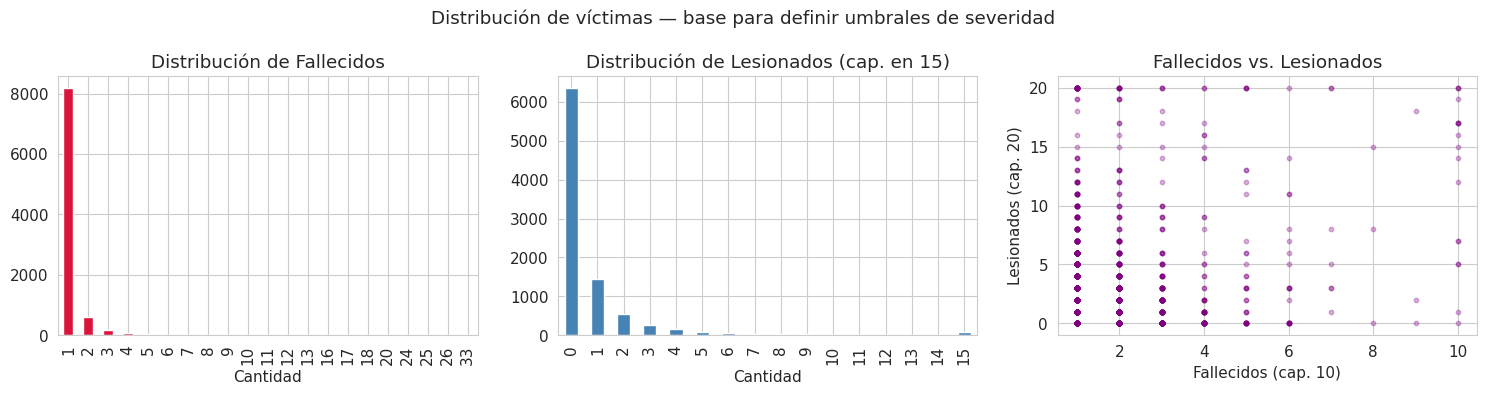

In [131]:
# Visualizar distribución conjunta antes de definir umbrales
if col_fall and col_les:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    df['FALLECIDOS'].value_counts().sort_index().plot(
        kind='bar', ax=axes[0], color='crimson')
    axes[0].set_title('Distribución de Fallecidos')
    axes[0].set_xlabel('Cantidad')

    df['LESIONADOS'].clip(upper=15).value_counts().sort_index().plot(
        kind='bar', ax=axes[1], color='steelblue')
    axes[1].set_title('Distribución de Lesionados (cap. en 15)')
    axes[1].set_xlabel('Cantidad')

    axes[2].scatter(df['FALLECIDOS'].clip(upper=10),
                    df['LESIONADOS'].clip(upper=20),
                    alpha=0.3, s=10, color='purple')
    axes[2].set_title('Fallecidos vs. Lesionados')
    axes[2].set_xlabel('Fallecidos (cap. 10)')
    axes[2].set_ylabel('Lesionados (cap. 20)')

    plt.suptitle('Distribución de víctimas — base para definir umbrales de severidad')
    plt.tight_layout()
    plt.savefig(DIR_FIGURAS / 'distribucion_victimas.png', dpi=150)
    plt.show()

In [132]:
# Aplicar categorías de severidad basadas en distribución observada
def categorizar_severidad(row):
    if row['FALLECIDOS'] >= 2:
        return 'GRAVE_MORTALIDAD'
    if row['LESIONADOS'] >= 3:
        return 'GRAVE_LESIONADOS'
    return 'LEVE'

df['CATEGORIA_SEVERIDAD'] = df.apply(categorizar_severidad, axis=1)

# Variables binarias auxiliares (útiles para análisis individual)
df['MORTALIDAD_MULTIPLE'] = (df['FALLECIDOS'] >= 2).astype(int)
df['LESION_MULTIPLE']     = (df['LESIONADOS'] >= 3).astype(int)

print('=== Distribución de CATEGORIA_SEVERIDAD ===')
conteo = df['CATEGORIA_SEVERIDAD'].value_counts()
print(conteo)
print('\nPorcentajes:')
print((conteo / len(df) * 100).round(1))

=== Distribución de CATEGORIA_SEVERIDAD ===
CATEGORIA_SEVERIDAD
LEVE                7652
GRAVE_MORTALIDAD     929
GRAVE_LESIONADOS     525
Name: count, dtype: int64

Porcentajes:
CATEGORIA_SEVERIDAD
LEVE                84.0
GRAVE_MORTALIDAD    10.2
GRAVE_LESIONADOS     5.8
Name: count, dtype: float64


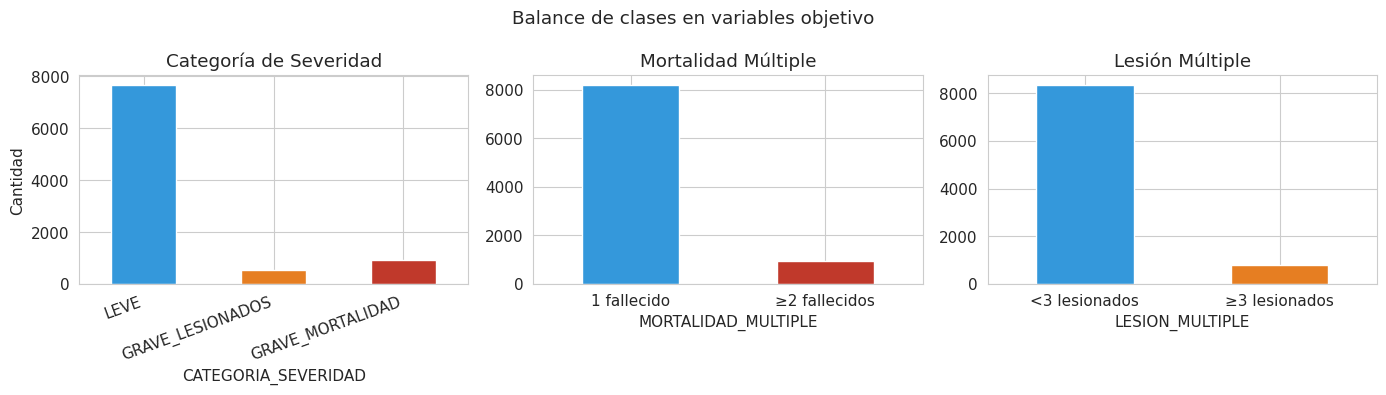


⚠ Si alguna clase tiene <10% del total, se requerirá SMOTE en la fase de modelado.


In [133]:
# Visualizar balance de clases
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

orden = ['LEVE', 'GRAVE_LESIONADOS', 'GRAVE_MORTALIDAD']
colores = ['#3498db', '#e67e22', '#c0392b']

df['CATEGORIA_SEVERIDAD'].value_counts().reindex(orden).plot(
    kind='bar', ax=axes[0], color=colores)
axes[0].set_title('Categoría de Severidad')
axes[0].set_ylabel('Cantidad')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=20, ha='right')

df['MORTALIDAD_MULTIPLE'].value_counts().rename({0:'1 fallecido', 1:'≥2 fallecidos'}).plot(
    kind='bar', ax=axes[1], color=['#3498db','#c0392b'])
axes[1].set_title('Mortalidad Múltiple')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=0)

df['LESION_MULTIPLE'].value_counts().rename({0:'<3 lesionados', 1:'≥3 lesionados'}).plot(
    kind='bar', ax=axes[2], color=['#3498db','#e67e22'])
axes[2].set_title('Lesión Múltiple')
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=0)

plt.suptitle('Balance de clases en variables objetivo')
plt.tight_layout()
plt.savefig(DIR_FIGURAS / 'balance_clases.png', dpi=150)
plt.show()

print('\n⚠ Si alguna clase tiene <10% del total, se requerirá SMOTE en la fase de modelado.')

## 7. Análisis Exploratorio

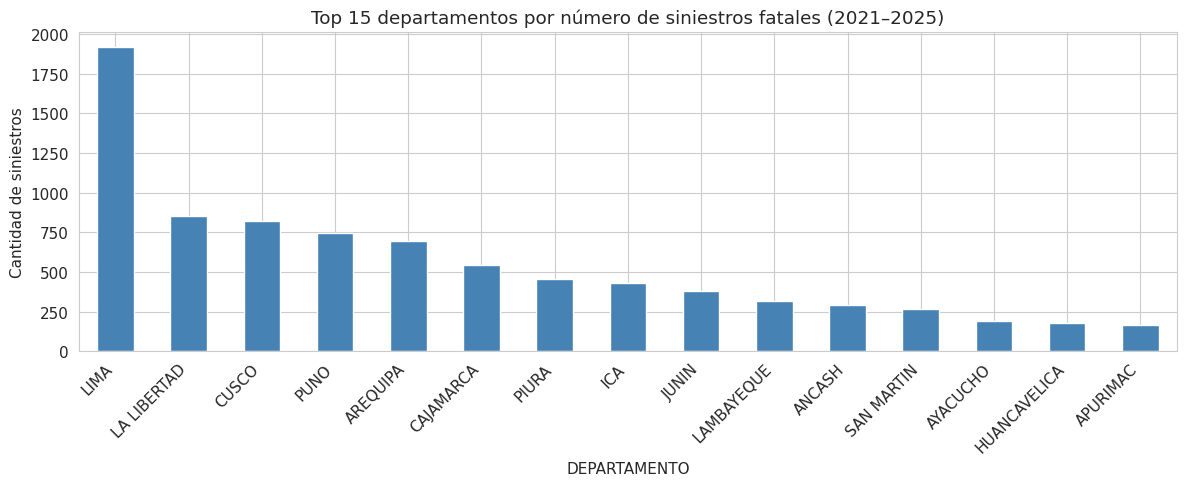

In [134]:
# --- 7.1 Top departamentos ---
if col_depto:
    top_deptos = df[col_depto].value_counts().head(15)
    fig, ax = plt.subplots(figsize=(12, 5))
    top_deptos.plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title('Top 15 departamentos por número de siniestros fatales (2021–2025)')
    ax.set_ylabel('Cantidad de siniestros')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(DIR_FIGURAS / 'siniestros_por_departamento.png', dpi=150)
    plt.show()

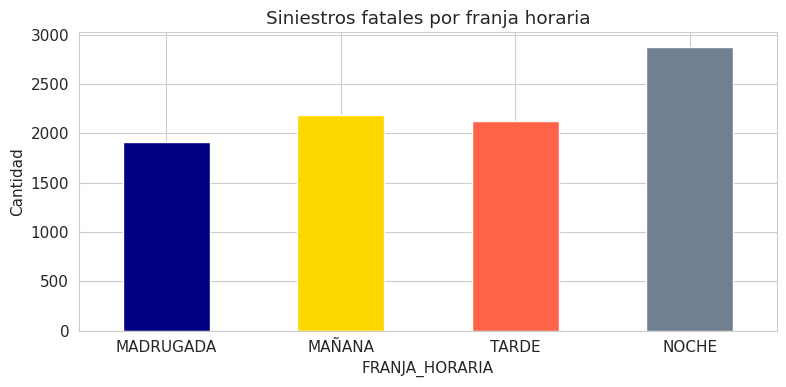

In [135]:
# --- 7.2 Franja horaria ---
if 'FRANJA_HORARIA' in df.columns:
    orden_franja = ['MADRUGADA', 'MAÑANA', 'TARDE', 'NOCHE', 'SIN_DATO']
    conteo_franja = df['FRANJA_HORARIA'].value_counts().reindex(
        [f for f in orden_franja if f in df['FRANJA_HORARIA'].values]
    )
    fig, ax = plt.subplots(figsize=(8, 4))
    conteo_franja.plot(kind='bar', ax=ax,
                       color=['navy','gold','tomato','slategray','gray'])
    ax.set_title('Siniestros fatales por franja horaria')
    ax.set_ylabel('Cantidad')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(DIR_FIGURAS / 'siniestros_por_franja.png', dpi=150)
    plt.show()

Columna causa detectada: CAUSA FACTOR PRINCIPAL


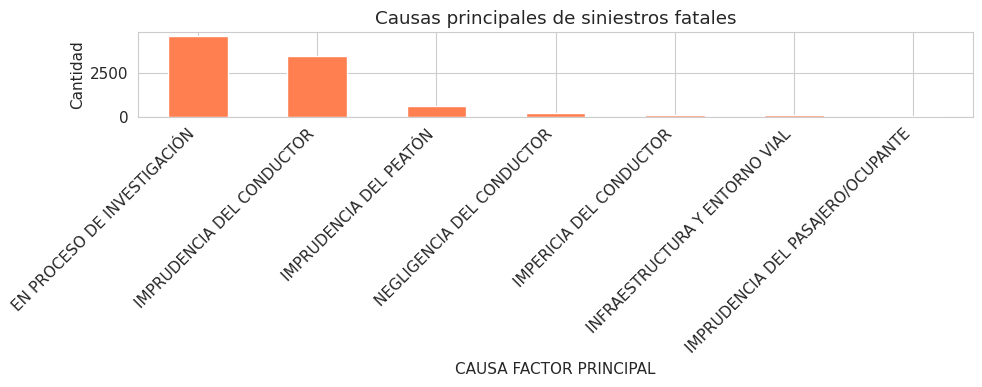

In [136]:
# --- 7.3 Causa principal ---
col_causa = next((c for c in df.columns if 'CAUSA' in c.upper() and 'PRINCIPAL' in c.upper()), None)
print(f'Columna causa detectada: {col_causa}')

if col_causa:
    causas = df[col_causa].value_counts()
    fig, ax = plt.subplots(figsize=(10, 4))
    causas.plot(kind='bar', ax=ax, color='coral')
    ax.set_title('Causas principales de siniestros fatales')
    ax.set_ylabel('Cantidad')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(DIR_FIGURAS / 'causas_principales.png', dpi=150)
    plt.show()

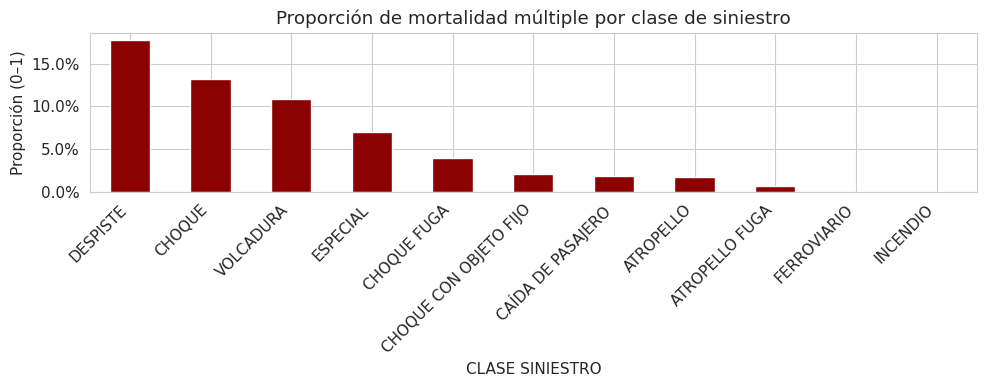

In [137]:
# --- 7.4 Severidad por clase de siniestro ---
col_clase = next((c for c in df.columns if 'CLASE' in c.upper()), None)

if col_clase and 'MORTALIDAD_MULTIPLE' in df.columns:
    pivot = df.groupby(col_clase)['MORTALIDAD_MULTIPLE'].mean().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(10, 4))
    pivot.plot(kind='bar', ax=ax, color='darkred')
    ax.set_title('Proporción de mortalidad múltiple por clase de siniestro')
    ax.set_ylabel('Proporción (0–1)')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(DIR_FIGURAS / 'mortalidad_por_clase.png', dpi=150)
    plt.show()

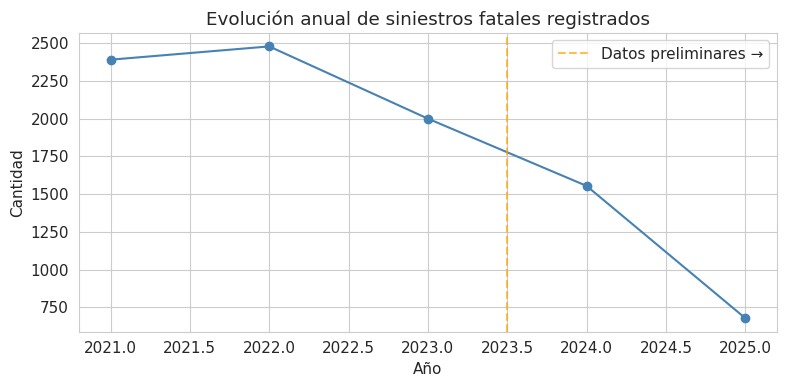

In [138]:
# --- 7.5 Evolución anual ---
if 'AÑO' in df.columns:
    anual = df.groupby('AÑO').size()
    fig, ax = plt.subplots(figsize=(8, 4))
    anual.plot(kind='line', marker='o', ax=ax, color='steelblue')
    ax.set_title('Evolución anual de siniestros fatales registrados')
    ax.set_ylabel('Cantidad')
    ax.set_xlabel('Año')
    # Nota: 2024-2025 son preliminares
    ax.axvline(2023.5, color='orange', linestyle='--', alpha=0.7,
               label='Datos preliminares →')
    ax.legend()
    plt.tight_layout()
    plt.savefig(DIR_FIGURAS / 'evolucion_anual.png', dpi=150)
    plt.show()

## 8. Exportación del dataset limpio

In [139]:
# Columnas originales relevantes — detectadas dinámicamente
# Se excluyen: CÓDIGO SINIESTRO (ID), FECHA_DT (ya procesada), columna de hora original
cols_excluir = ['CÓDIGO SINIESTRO', 'FECHA_DT', col_hora, col_fecha]
cols_excluir = [c for c in cols_excluir if c and c in df.columns]

df_modelo = df.drop(columns=cols_excluir, errors='ignore').copy()

# Exportar con encoding utf-8 explícito y sobrescribir si ya existe
RUTA_SALIDA = DIR_PROCESADA / 'siniestros_limpio.csv'
df_modelo.to_csv(RUTA_SALIDA, index=False, encoding='utf-8')

print(f'✓ Dataset limpio exportado: {df_modelo.shape[0]:,} filas × {df_modelo.shape[1]} columnas')
print(f'  Registros preservados: 100% (ninguna fila eliminada)')
print('\nColumnas en el dataset final:')
for col in df_modelo.columns:
    print(f'  {col}')

✓ Dataset limpio exportado: 9,106 filas × 36 columnas
  Registros preservados: 100% (ninguna fila eliminada)

Columnas en el dataset final:
  CLASE SINIESTRO
  CANTIDAD DE FALLECIDOS
  CANTIDAD DE LESIONADOS
  CANTIDAD DE VEHICULOS DAÑADOS
  DEPARTAMENTO
  PROVINCIA
  DISTRITO
  ZONA
  TIPO DE VÍA
  RED VIAL
  COD CARRETERA
  COORDENADAS LATITUD
  COORDENADAS  LONGITUD
  CONDICIÓN CLIMÁTICA
  ZONIFICACIÓN
  CARACTERÍSTICAS DE VÍA
  PERFIL LONGITUDINAL VÍA
  SUPERFICIE DE CALZADA
  ¿EXISTE SEÑAL VERTICAL?
  CLASIFICACIÓN DE LA SEÑAL VERTICAL Nº 1
  CLASIFICACIÓN DE LA SEÑAL VERTICAL Nº 2
  ¿EXISTE SEÑAL HORIZONTAL?
  CAUSA FACTOR PRINCIPAL
  CAUSA ESPECÍFICA
  AÑO
  MES
  DIA_SEMANA
  ES_FIN_SEMANA
  HORA_NUM
  FRANJA_HORARIA
  REGION_NATURAL
  FALLECIDOS
  LESIONADOS
  CATEGORIA_SEVERIDAD
  MORTALIDAD_MULTIPLE
  LESION_MULTIPLE


In [140]:
# Resumen final
print('=' * 55)
print('RESUMEN DEL PROCESO EDA Y LIMPIEZA')
print('=' * 55)
print(f'Registros totales:          {len(df):,}')
print(f'Columnas originales:        {df_raw.shape[1]}')
print(f'Columnas en dataset final:  {df_modelo.shape[1]}')
print(f'Filas eliminadas:           0')
print(f'Columnas imputadas (cat.):  {len(cols_cat_nulos)}')
print(f'Columnas imputadas (num.):  {len(cols_num_nulos)}')
print('\nVariables objetivo creadas:')
print('  CATEGORIA_SEVERIDAD   — 3 clases ordinales')
print('  MORTALIDAD_MULTIPLE   — binaria (fallecidos ≥ 2)')
print('  LESION_MULTIPLE       — binaria (lesionados ≥ 3)')
print('\nSiguiente paso: Modelado supervisado + DBSCAN hotspots')

RESUMEN DEL PROCESO EDA Y LIMPIEZA
Registros totales:          9,106
Columnas originales:        27
Columnas en dataset final:  36
Filas eliminadas:           0
Columnas imputadas (cat.):  0
Columnas imputadas (num.):  1

Variables objetivo creadas:
  CATEGORIA_SEVERIDAD   — 3 clases ordinales
  MORTALIDAD_MULTIPLE   — binaria (fallecidos ≥ 2)
  LESION_MULTIPLE       — binaria (lesionados ≥ 3)

Siguiente paso: Modelado supervisado + DBSCAN hotspots


## 9. Análisis visual sobre el dataset limpio

Las visualizaciones anteriores son de diagnóstico.
Las siguientes son analíticas, exploran patrones en los datos ya limpios.
Se ejecutan después de la exportación para no depender del proceso de limpieza.

### 9.1 Mapa de calor de correlaciones

Se evalúan las correlaciones entre variables numéricas para detectar multicolinealidad
antes del modelado. Variables altamente correladas entre sí aportan información redundante
al modelo (Provost & Fawcett, 2013).

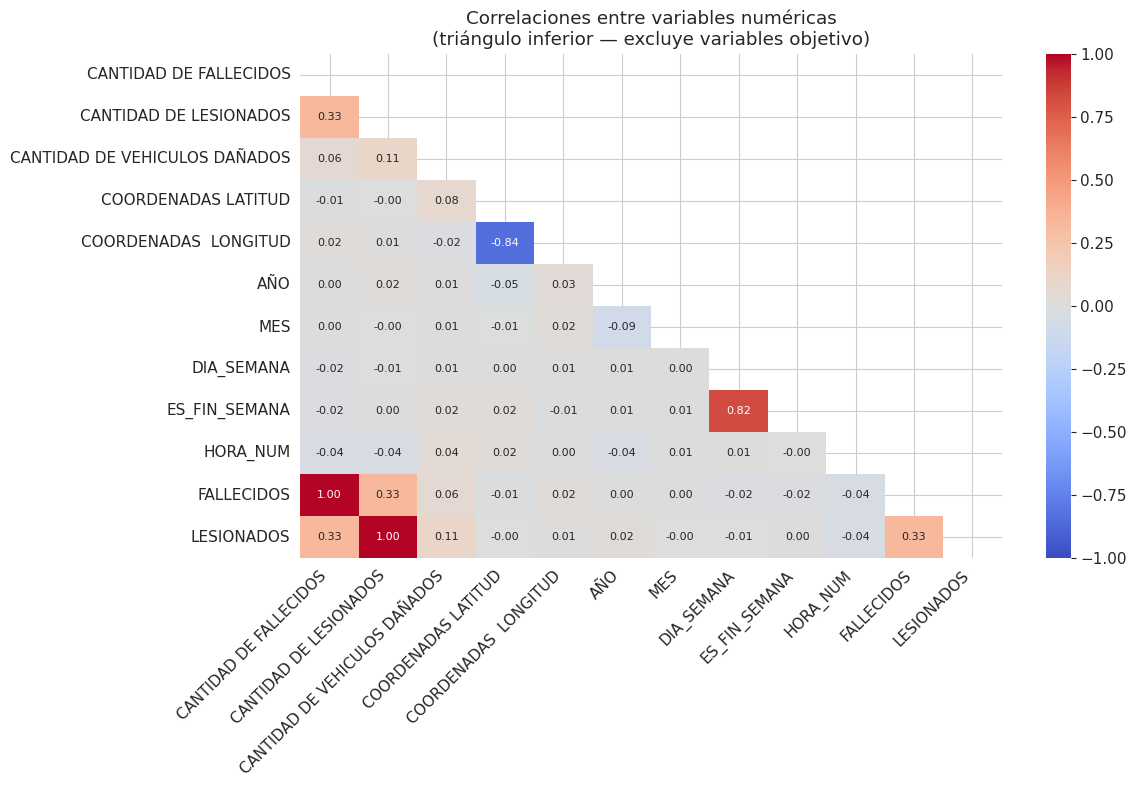

Pares con correlación alta (|r| > 0.7):
  CANTIDAD DE FALLECIDOS ↔ FALLECIDOS: 1.0
  CANTIDAD DE LESIONADOS ↔ LESIONADOS: 1.0
  COORDENADAS LATITUD ↔ COORDENADAS  LONGITUD: -0.843
  DIA_SEMANA ↔ ES_FIN_SEMANA: 0.824


In [141]:
cols_numericas_analisis = df_modelo.select_dtypes(include=np.number).columns.tolist()
# Excluir variables objetivo del análisis de correlación
excluir_corr = ['MORTALIDAD_MULTIPLE', 'LESION_MULTIPLE']
cols_corr = [c for c in cols_numericas_analisis if c not in excluir_corr]

corr_matrix = df_modelo[cols_corr].corr()

fig, ax = plt.subplots(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Correlaciones entre variables numéricas\n(triángulo inferior — excluye variables objetivo)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(DIR_FIGURAS / 'correlaciones_numericas.png', dpi=150)
plt.show()

# Identificar pares con correlación alta (>0.7 o <-0.7)
corr_alta = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.7:
            corr_alta.append((corr_matrix.columns[i], corr_matrix.columns[j], round(val, 3)))

if corr_alta:
    print('Pares con correlación alta (|r| > 0.7):')
    for a, b, v in corr_alta:
        print(f'  {a} ↔ {b}: {v}')
else:
    print('No se detectaron pares con correlación alta (|r| > 0.7)')

### 9.2 Severidad por variables clave

Se cruza `CATEGORIA_SEVERIDAD` con las variables categóricas más relevantes
para identificar patrones que el modelo deberá capturar.

Variables detectadas para cruce: ['ZONA', 'RED VIAL', 'CONDICIÓN CLIMÁTICA', 'FRANJA_HORARIA', 'REGION_NATURAL']


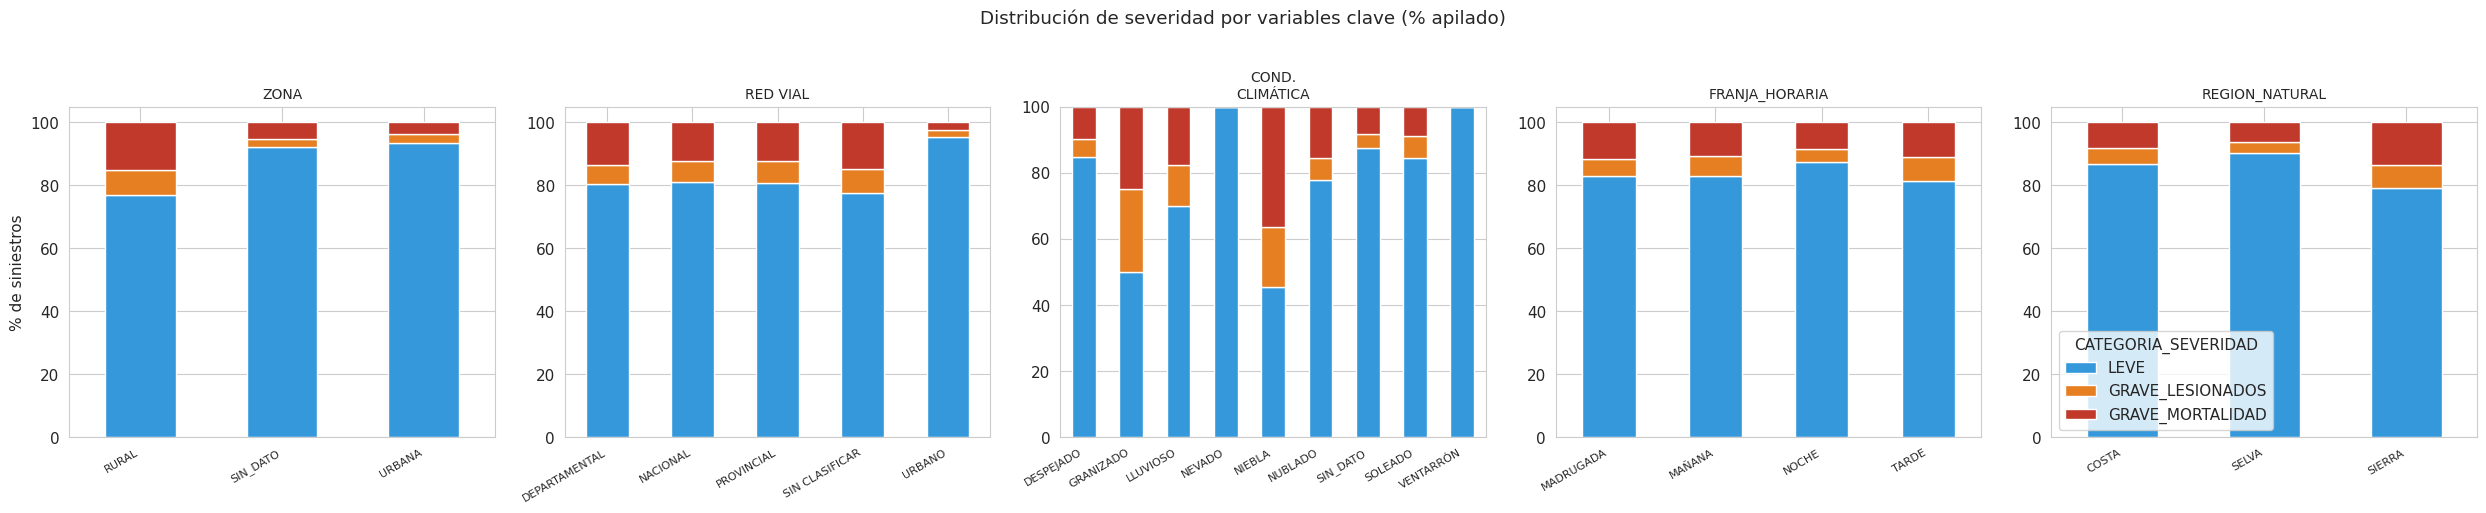

In [142]:
# Variables categóricas a cruzar con severidad
vars_cruce = []
candidatas = ['ZONA', 'RED VIAL', 'CONDICIÓN CLIMÁTICA', 'FRANJA_HORARIA', 'REGION_NATURAL']
for c in candidatas:
    match = next((col for col in df_modelo.columns if c.upper() in col.upper()), None)
    if match:
        vars_cruce.append(match)

print(f'Variables detectadas para cruce: {vars_cruce}')

n = len(vars_cruce)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
if n == 1:
    axes = [axes]

orden_sev = ['LEVE', 'GRAVE_LESIONADOS', 'GRAVE_MORTALIDAD']
colores_sev = ['#3498db', '#e67e22', '#c0392b']

for ax, var in zip(axes, vars_cruce):
    tabla = (
        df_modelo.groupby([var, 'CATEGORIA_SEVERIDAD'])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=[s for s in orden_sev if s in df_modelo['CATEGORIA_SEVERIDAD'].unique()])
    )
    tabla_pct = tabla.div(tabla.sum(axis=1), axis=0) * 100
    tabla_pct.plot(
        kind='bar', stacked=True, ax=ax,
        color=colores_sev[:tabla_pct.shape[1]],
        legend=(var == vars_cruce[-1])
    )
    ax.set_title(var.replace('CONDICIÓN ', 'COND.\n'), fontsize=10)
    ax.set_ylabel('% de siniestros' if var == vars_cruce[0] else '')
    ax.set_xlabel('')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)

fig.suptitle('Distribución de severidad por variables clave (% apilado)', y=1.02)
plt.tight_layout()
plt.savefig(DIR_FIGURAS / 'severidad_por_variables.png', dpi=150, bbox_inches='tight')
plt.show()

### 9.3 Mapa geográfico de siniestros por severidad

Scatter plot de coordenadas geográficas coloreado por `CATEGORIA_SEVERIDAD`.
Permite identificar visualmente la distribución espacial de los eventos graves
y motiva el análisis de clustering espacial del notebook 05 (DBSCAN).

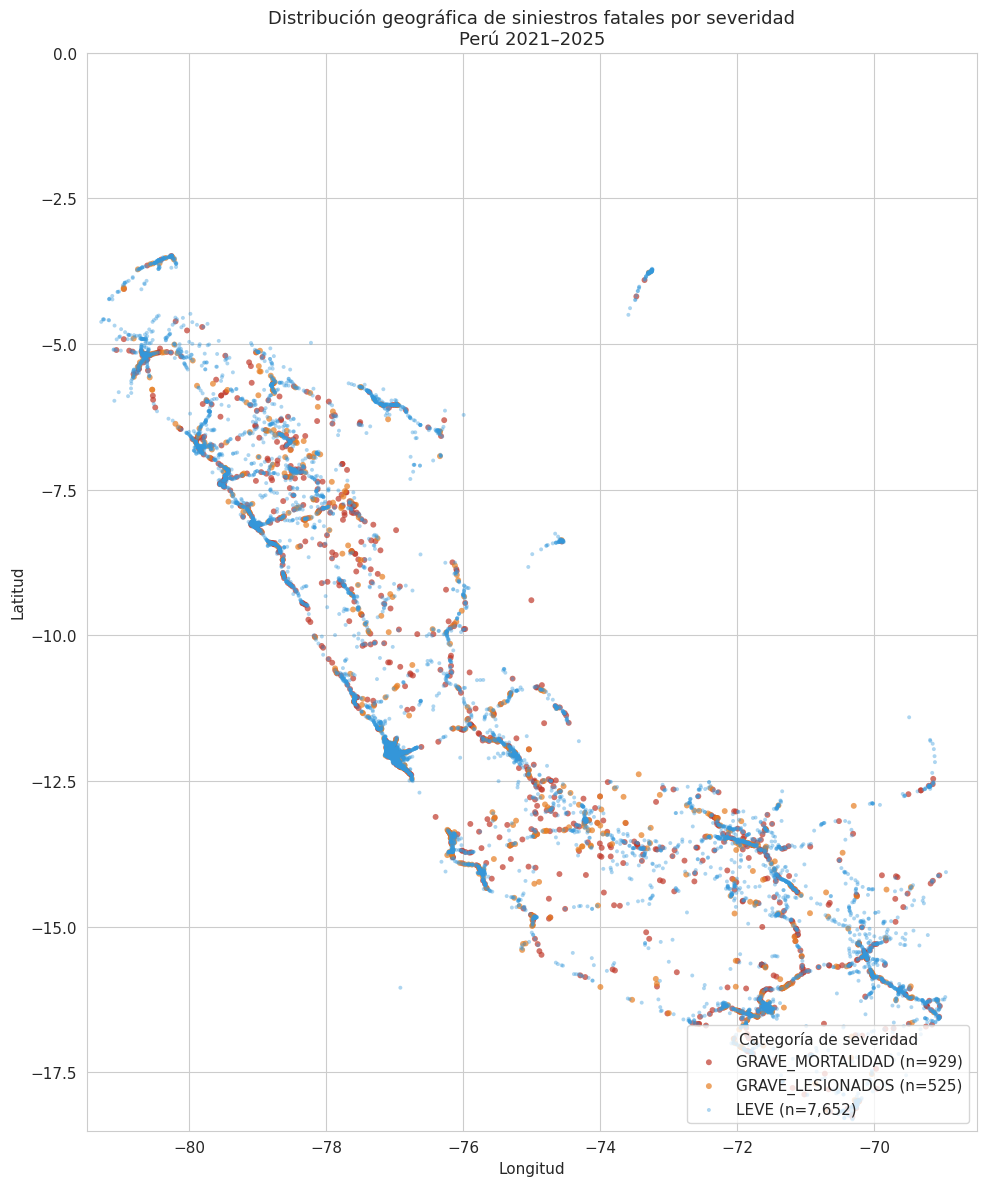


Nota: los clusters visibles en este mapa son la motivación del análisis DBSCAN (notebook 05).


In [143]:
col_lat_m = next((c for c in df_modelo.columns if 'LATITUD' in c.upper()), None)
col_lon_m = next((c for c in df_modelo.columns if 'LONGITUD' in c.upper()), None)

if col_lat_m and col_lon_m:
    colores_mapa = {'LEVE': '#3498db', 'GRAVE_LESIONADOS': '#e67e22', 'GRAVE_MORTALIDAD': '#c0392b'}
    orden_plot = ['GRAVE_MORTALIDAD', 'GRAVE_LESIONADOS', 'LEVE']

    fig, ax = plt.subplots(figsize=(10, 12))

    # Plotear en orden inverso para que los graves queden encima
    for categoria in orden_plot:
        if categoria not in df_modelo['CATEGORIA_SEVERIDAD'].values:
            continue
        subset = df_modelo[df_modelo['CATEGORIA_SEVERIDAD'] == categoria]
        ax.scatter(
            subset[col_lon_m],
            subset[col_lat_m],
            c=colores_mapa[categoria],
            label=f'{categoria} (n={len(subset):,})',
            alpha=0.4 if categoria == 'LEVE' else 0.7,
            s=8 if categoria == 'LEVE' else 18,
            edgecolors='none'
        )

    ax.set_title('Distribución geográfica de siniestros fatales por severidad\nPerú 2021–2025', fontsize=13)
    ax.set_xlabel('Longitud')
    ax.set_ylabel('Latitud')
    ax.legend(title='Categoría de severidad', loc='lower right')

    # Límites aproximados del territorio peruano
    ax.set_xlim(-81.5, -68.5)
    ax.set_ylim(-18.5, -0.0)

    plt.tight_layout()
    plt.savefig(DIR_FIGURAS / 'mapa_geografico_severidad.png', dpi=150)
    plt.show()

    print('\nNota: los clusters visibles en este mapa son la motivación del análisis DBSCAN (notebook 05).')
else:
    print('No se encontraron columnas de coordenadas en el dataset limpio.')